El siguiente codigo tiene como objetivo hacer una carga inicial de los datos del csv para irlos procesando en el transcurso del análisis e importar desde un inicio las principales librerias a utilizar en todo el proyecto.

In [1]:
# ==========================================
# CELDA 1: CARGA Y PREPARACIÓN DE DATOS
# ==========================================

import pandas as pd
import numpy as np
import jinja2
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import skew, kurtosis
import os
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import spearmanr



# Ruta del archivo
CSV_PATH = "regular_season_totals_2010_2024.csv"

# Cargar dataset
df = pd.read_csv(CSV_PATH)

# Información básica
print("=== INFORMACIÓN GENERAL DEL DATASET ===")
print(f"Registros: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")
print("\nPrimeras filas:")
display(df.head())

# Conversión explícita de tipos si fuera necesario
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

print("\nCarga completada correctamente.")


=== INFORMACIÓN GENERAL DEL DATASET ===
Registros: 33316
Variables: 57

Primeras filas:


,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,AVAILABLE_FLAG
0,2022-23,1610612744,GSW,Golden State Warriors,22201230,2023-04-09T00:00:00,GSW @ POR,W,48.0,58,...,1,1578,55,512,457,678,2455,3,1,1.0
1,2020-21,1610612749,MIL,Milwaukee Bucks,22000051,2020-12-29T00:00:00,MIL @ MIA,W,48.0,51,...,146,1636,33,1830,1361,1552,1220,14,7,1.0
2,2013-14,1610612751,BKN,Brooklyn Nets,21300359,2013-12-16T00:00:00,BKN vs. PHI,W,48.0,47,...,22,2280,406,1979,1,1004,453,19,12,1.0
3,2013-14,1610612757,POR,Portland Trail Blazers,21300347,2013-12-14T00:00:00,POR @ PHI,W,48.0,52,...,2,2065,628,204,1269,272,2190,4,15,1.0
4,2018-19,1610612745,HOU,Houston Rockets,21801200,2019-04-07T00:00:00,HOU vs. PHX,W,48.0,53,...,84,176,149,917,1,244,1725,4,20,1.0



Carga completada correctamente.


EL siguiente codigo va a realizar el análisis descriptivo de las columnas del csv que se van a utilizar

In [3]:
# ==========================================
# FUNCIÓN DE ESTADÍSTICOS DESCRIPTIVOS (EDA)
# ==========================================

def estadisticos_descriptivos_eda(
    data: pd.DataFrame,
    variables: list,
    export_tex: bool = False,
    tex_filename: str = "estadisticos_descriptivos_eda.tex"
):
    """
    Calcula estadísticos descriptivos para análisis exploratorio (EDA)
    y exporta la tabla a LaTeX sin errores de compilación.
    """

    stats = pd.DataFrame(index=[
        "Media",
        "Mediana",
        "Moda",
        "Desv. Estándar",
        "Varianza",
        "Coef. Var. (%)",
        "Mínimo",
        "Máximo",
        "Rango",
        "Q1",
        "Q3",
        "IQR"
    ])

    for var in variables:
        serie = data[var].dropna()

        stats.loc["Media", var] = serie.mean()
        stats.loc["Mediana", var] = serie.median()
        stats.loc["Moda", var] = serie.mode().iloc[0] if not serie.mode().empty else np.nan
        stats.loc["Desv. Estándar", var] = serie.std()
        stats.loc["Varianza", var] = serie.var()
        stats.loc["Coef. Var. (%)", var] = (
            serie.std() / serie.mean() * 100 if serie.mean() != 0 else np.nan
        )
        stats.loc["Mínimo", var] = serie.min()
        stats.loc["Máximo", var] = serie.max()
        stats.loc["Rango", var] = serie.max() - serie.min()
        stats.loc["Q1", var] = serie.quantile(0.25)
        stats.loc["Q3", var] = serie.quantile(0.75)
        stats.loc["IQR", var] = serie.quantile(0.75) - serie.quantile(0.25)

    # Limpieza segura para LaTeX
    stats = (
        stats.round(3)
             .replace([np.inf, -np.inf], np.nan)
             .fillna("--")
    )

    print("\n=== ESTADÍSTICOS DESCRIPTIVOS (EDA) ===\n")
    display(stats)

    if export_tex:
        latex_table = stats.to_latex(
            column_format="|l|" + "c|" * len(variables),
            caption="Estadísticos descriptivos para el análisis exploratorio de datos",
            label="tab:estadisticos_descriptivos_eda",
            escape=True
        )

        output_dir = "latex_tables"
        os.makedirs(output_dir, exist_ok=True)
        tex_path = os.path.join(output_dir, tex_filename)

        with open(tex_path, "w", encoding="utf-8") as f:
            f.write(latex_table)

        print(f"✔ Archivo LaTeX generado: {tex_path}")

    return stats


In [6]:
# ==========================================
# EJECUCIÓN DEL ANÁLISIS DESCRIPTIVO (EDA)
# ==========================================

variables_analisis = [
    "PTS",
    "REB",
    "AST",
    "STL",
    "BLK",
    "PLUS_MINUS"
]
variables_analisis1 = [
    "FG3M",
    "FG3A",
    "FG3_PCT",
    "FG_PCT",
    "FT_PCT",
    "TOV"
]

address = "estadisticos_descriptivos_eda1.tex"
estadisticos = estadisticos_descriptivos_eda(
    data=df,
    variables=variables_analisis,
    export_tex=True   # Cambia a False si no deseas generar el archivo .tex
)

estadisticos = estadisticos_descriptivos_eda(
    data=df,
    variables=variables_analisis1,
    export_tex=True,
    tex_filename=address
)




=== ESTADÍSTICOS DESCRIPTIVOS (EDA) ===



,PTS,REB,AST,STL,BLK,PLUS_MINUS
Media,106.040,43.444,23.384,7.624,4.879,0.0
Mediana,106.000,43.000,23.000,7.000,5.000,0.0
Moda,104.000,43.000,24.000,7.000,4.000,-7.0
Desv. Estándar,13.587,6.599,5.267,2.899,2.535,14.171
Varianza,184.599,43.552,27.740,8.406,6.428,200.816
Coef. Var. (%),12.813,15.191,22.523,38.031,51.965,--
Mínimo,56.000,17.000,4.000,0.000,0.000,-73.0
Máximo,176.000,81.000,50.000,22.000,20.000,73.0
Rango,120.000,64.000,46.000,22.000,20.000,146.0
Q1,97.000,39.000,20.000,6.000,3.000,-9.0


✔ Archivo LaTeX generado: latex_tables\estadisticos_descriptivos_eda.tex

=== ESTADÍSTICOS DESCRIPTIVOS (EDA) ===



,FG3M,FG3A,FG3_PCT,FG_PCT,FT_PCT,TOV
Media,9.870,27.547,0.356,0.460,0.767,14.202
Mediana,10.000,27.000,0.355,0.459,0.773,14.000
Moda,9.000,26.000,0.333,0.500,0.750,14.000
Desv. Estándar,4.255,9.153,0.098,0.056,0.103,3.905
Varianza,18.104,83.785,0.010,0.003,0.011,15.247
Coef. Var. (%),43.110,33.228,27.397,12.071,13.471,27.494
Mínimo,0.000,3.000,0.000,0.246,0.000,1.000
Máximo,29.000,70.000,0.842,0.687,1.000,31.000
Rango,29.000,67.000,0.842,0.441,1.000,30.000
Q1,7.000,21.000,0.292,0.422,0.700,11.000


✔ Archivo LaTeX generado: latex_tables\estadisticos_descriptivos_eda1.tex


Genera la tabla de distribución de la variable WL (Win/Loss).  para ver como estan distribuidos los datos de los partidos ganados y perdidos

In [8]:
# ==========================================
# DISTRIBUCIÓN DE RESULTADOS (WL)
# ==========================================

def tabla_wl(data, export_tex=False, tex_filename="distribucion_WL.tex"):
    """
    Genera la tabla de distribución de la variable WL (Win/Loss).
    Opcionalmente exporta la tabla a formato LaTeX.
    """

    # Conteo de resultados
    conteo = data["WL"].value_counts().sort_index()
    total = conteo.sum()

    # DataFrame final
    tabla = pd.DataFrame({
        "Resultado": conteo.index.map({"W": "Victoria (W)", "L": "Derrota (L)"}),
        "Frecuencia": conteo.values,
        "Porcentaje": (conteo.values / total * 100).round(2)
    })

    # Mostrar en consola
    print("\nDistribución de Resultados (WL):")
    print(tabla.to_string(index=False))

    # Exportar a LaTeX si se solicita
    if export_tex:
        latex_table = tabla.to_latex(
            index=False,
            column_format="|c|c|c|",
            caption="Distribución de resultados de partidos",
            label="tab:distribucion_wl",
            escape=False
        )

        with open(tex_filename, "w", encoding="utf-8") as f:
            f.write(r"\begin{table}[H]" + "\n")
            f.write(r"\centering" + "\n")
            f.write(latex_table + "\n")
            f.write(r"\end{table}")

        print(f"\nArchivo LaTeX generado: {tex_filename}")

    return tabla


In [9]:
tabla_wl(
    data=df,
    export_tex=True   # Cambia a False si no quieres generar el .tex
)



Distribución de Resultados (WL):
   Resultado  Frecuencia  Porcentaje
 Derrota (L)       16658        50.0
Victoria (W)       16658        50.0

Archivo LaTeX generado: distribucion_WL.tex


,Resultado,Frecuencia,Porcentaje
0,Derrota (L),16658,50.0
1,Victoria (W),16658,50.0


Creación de histogramas y gráficas de frecuencia acumulada para los valores principales a analizar

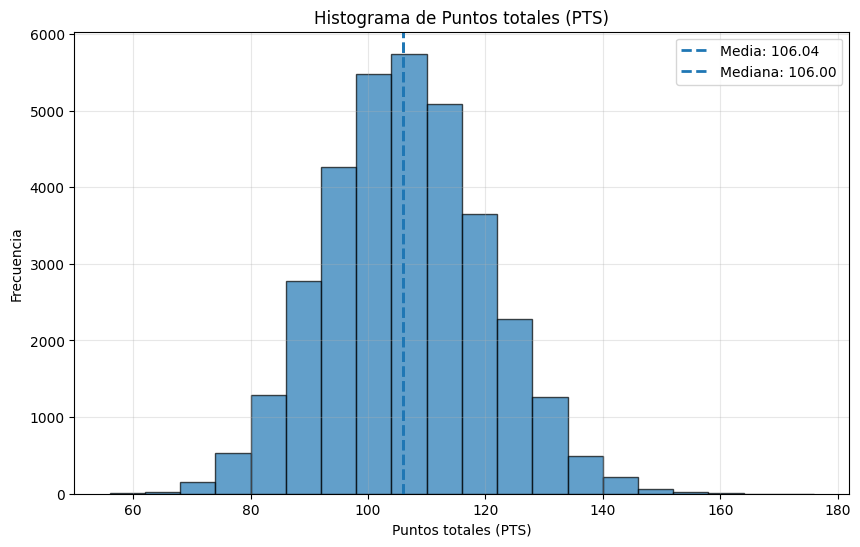

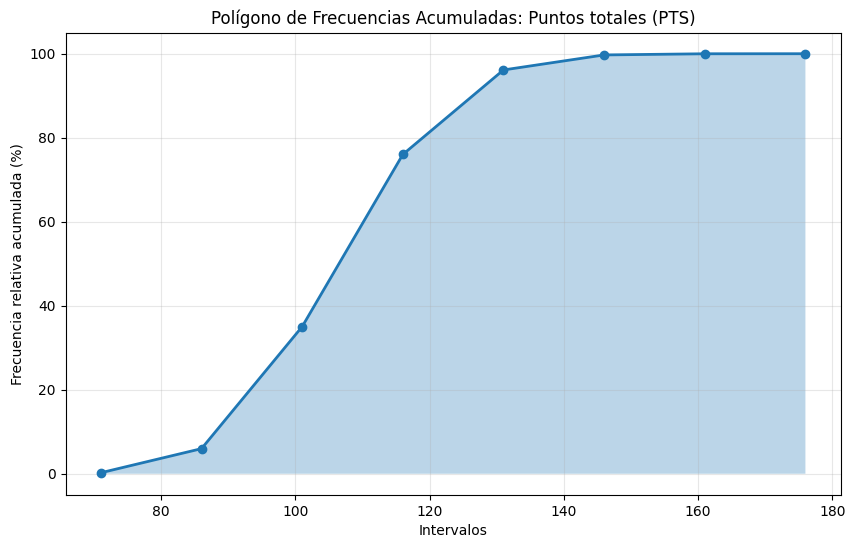

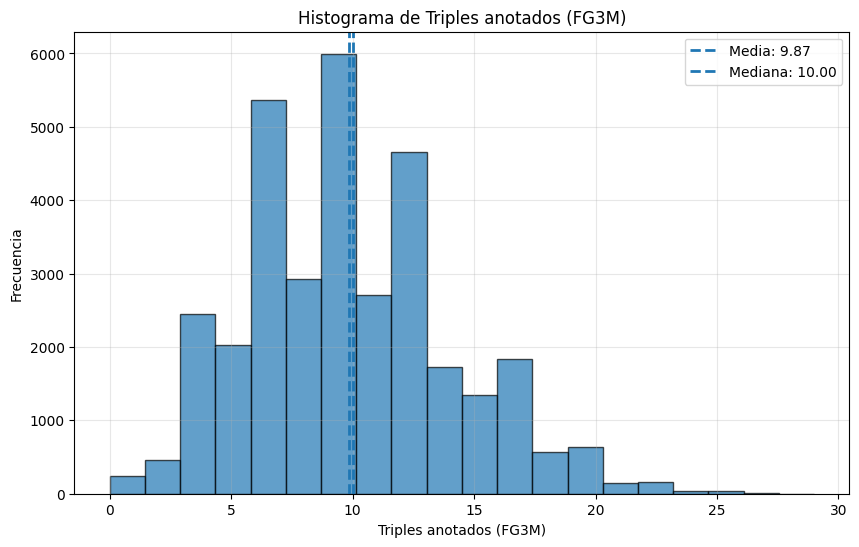

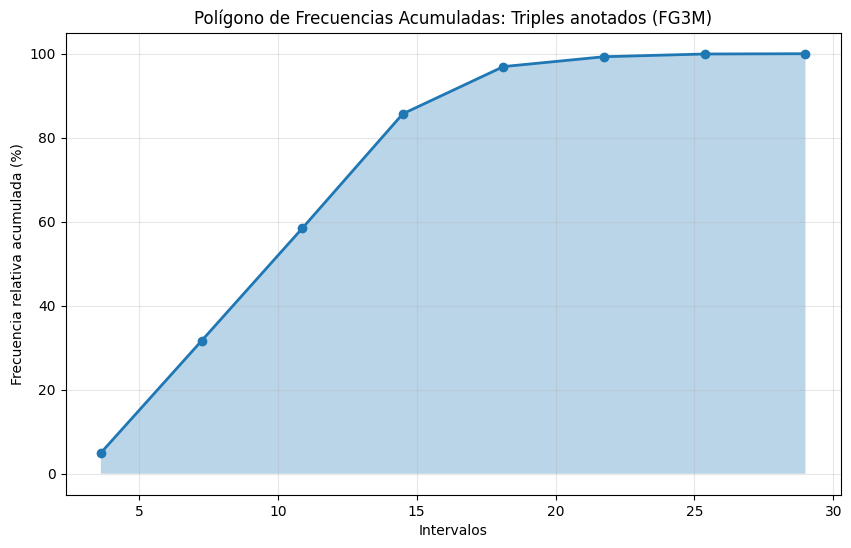

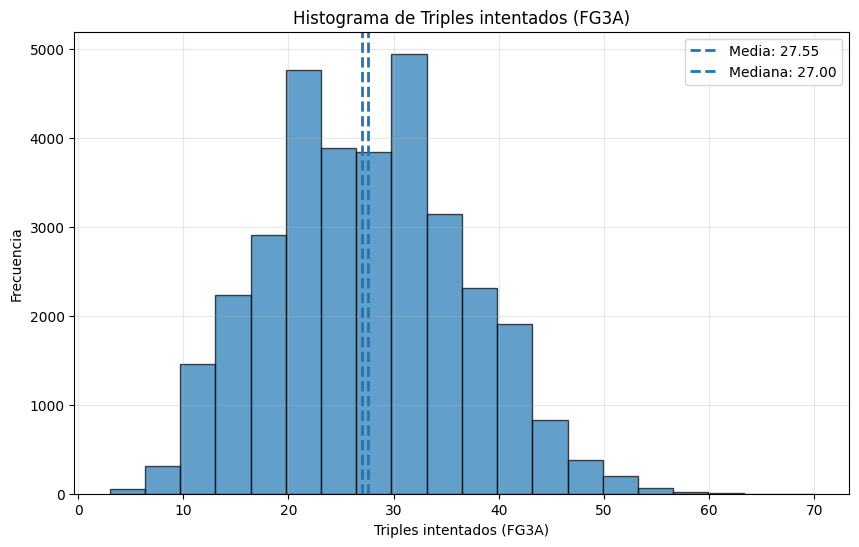

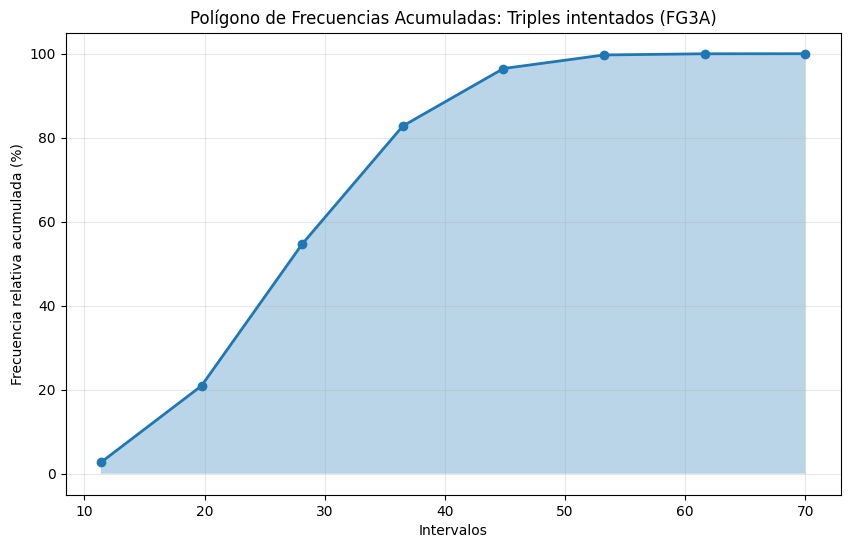

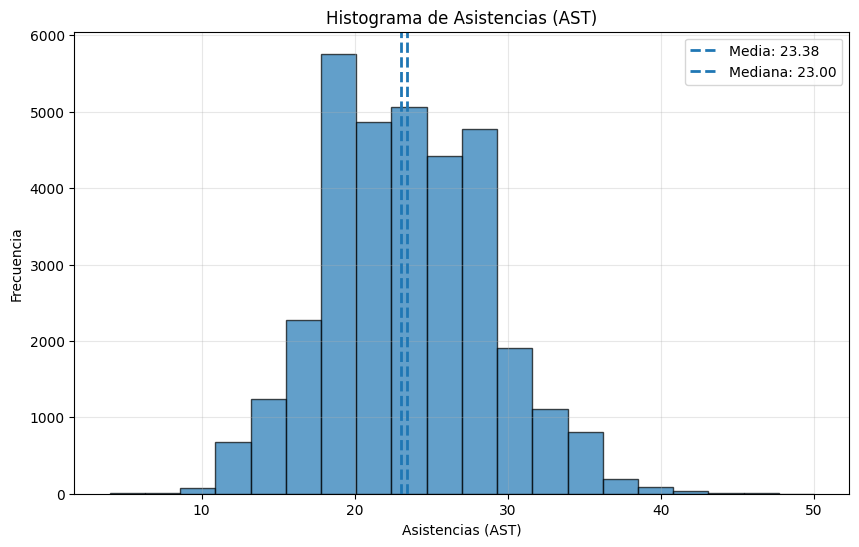

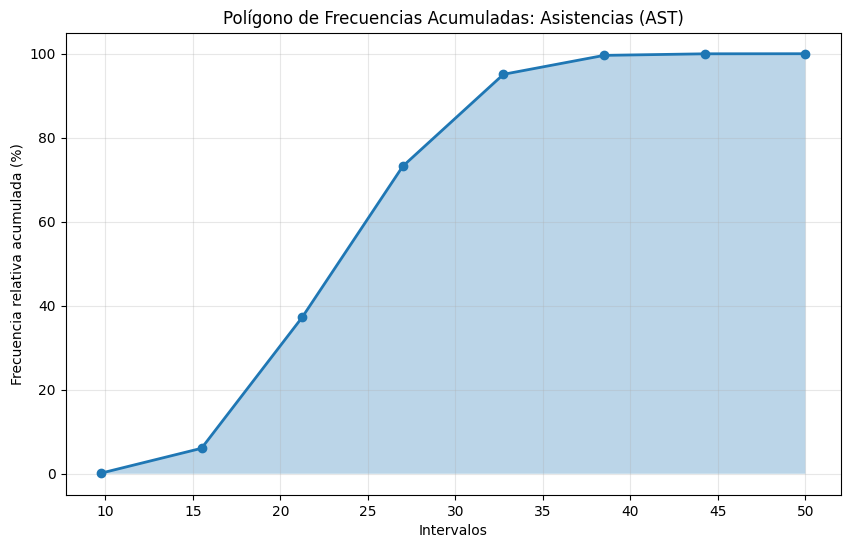

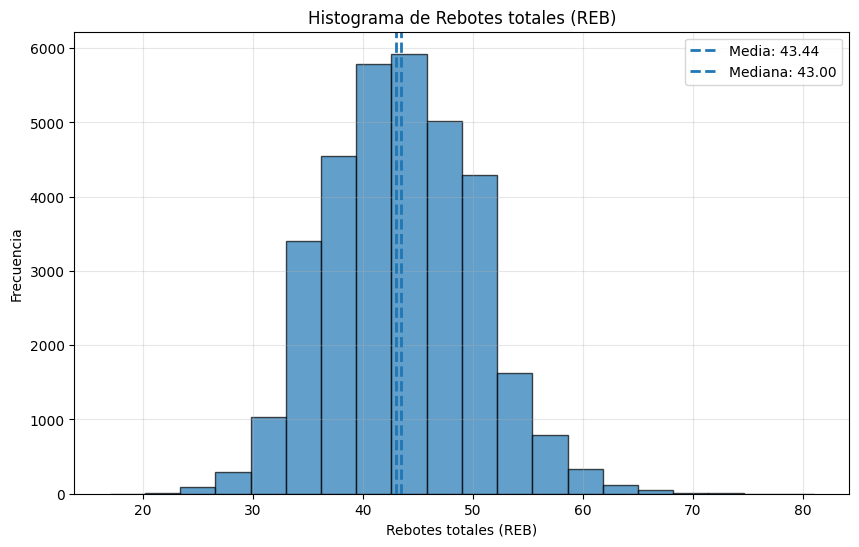

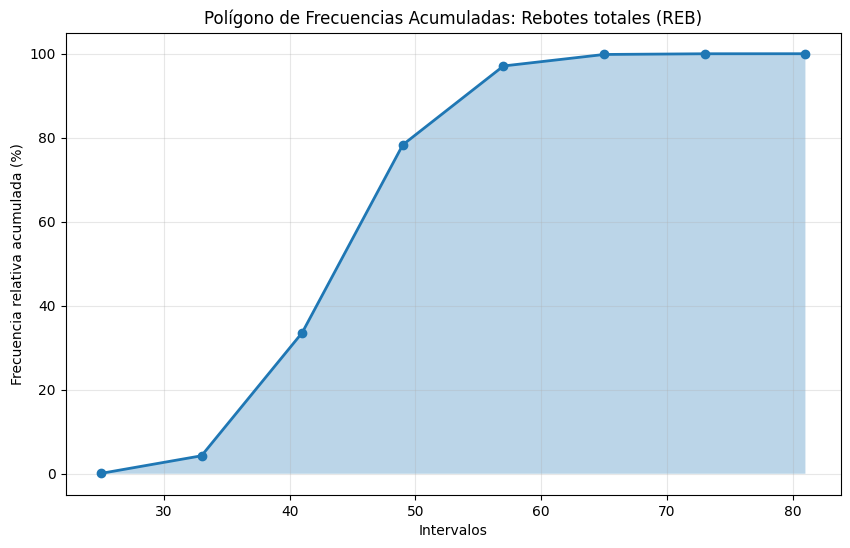

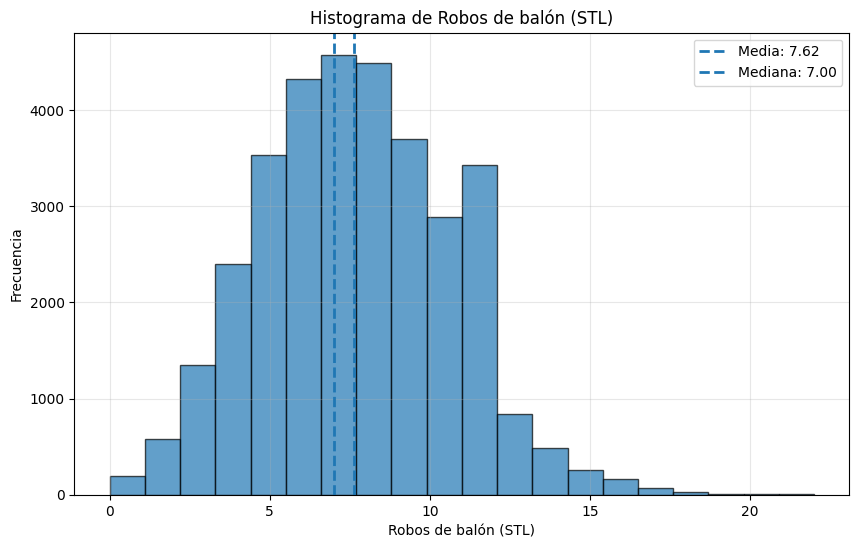

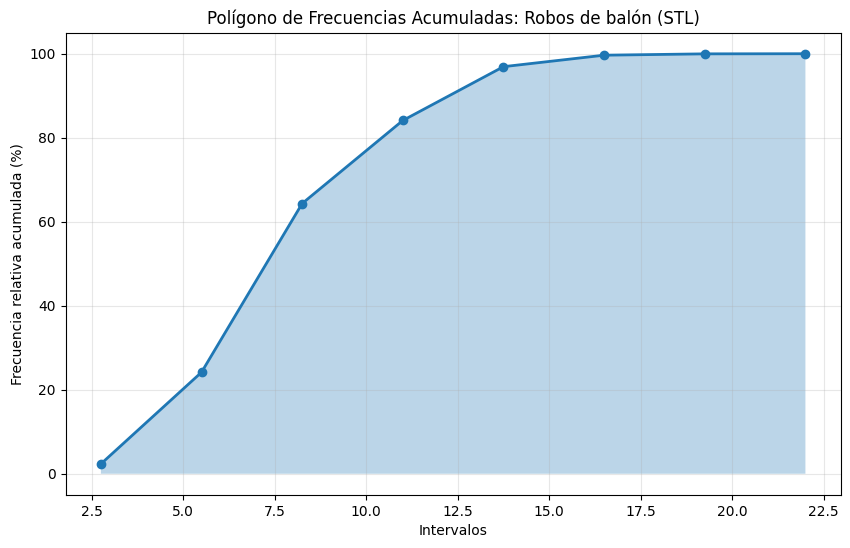

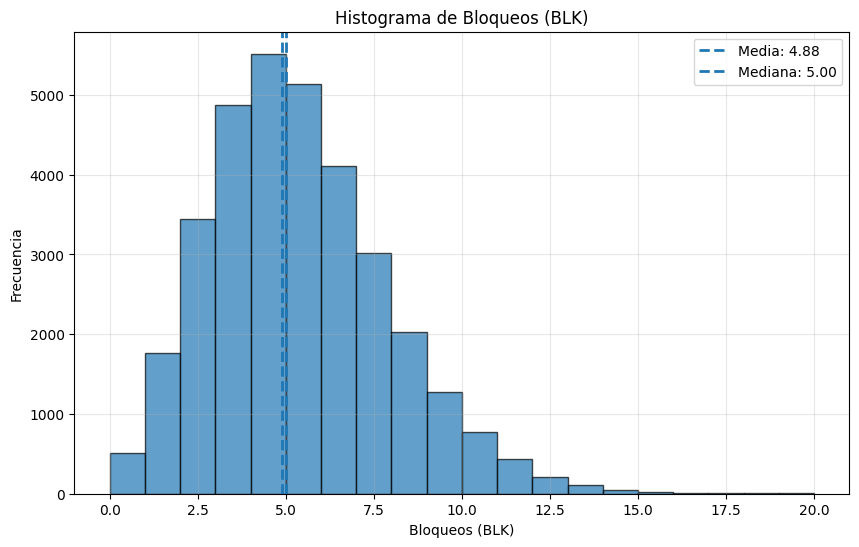

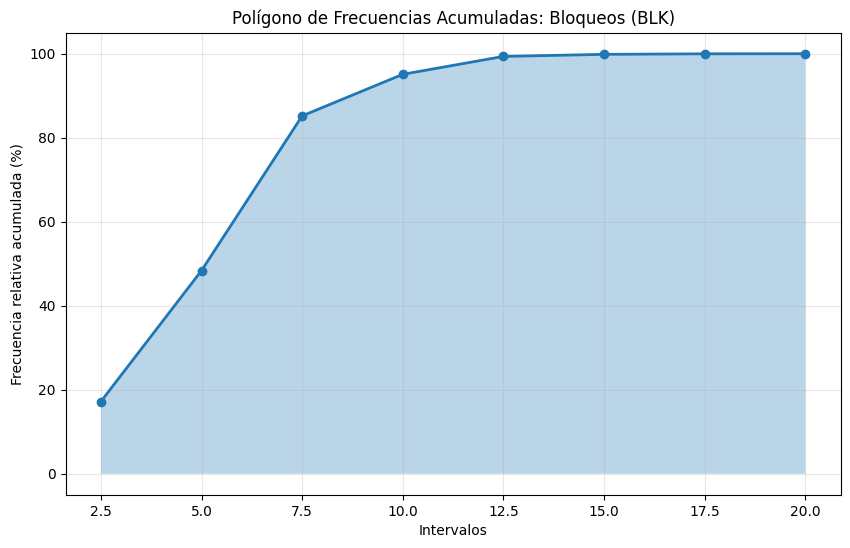

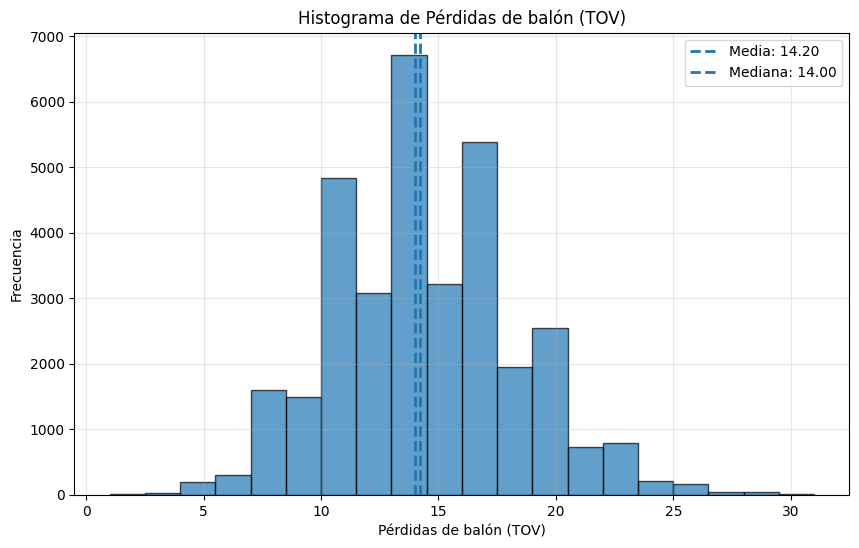

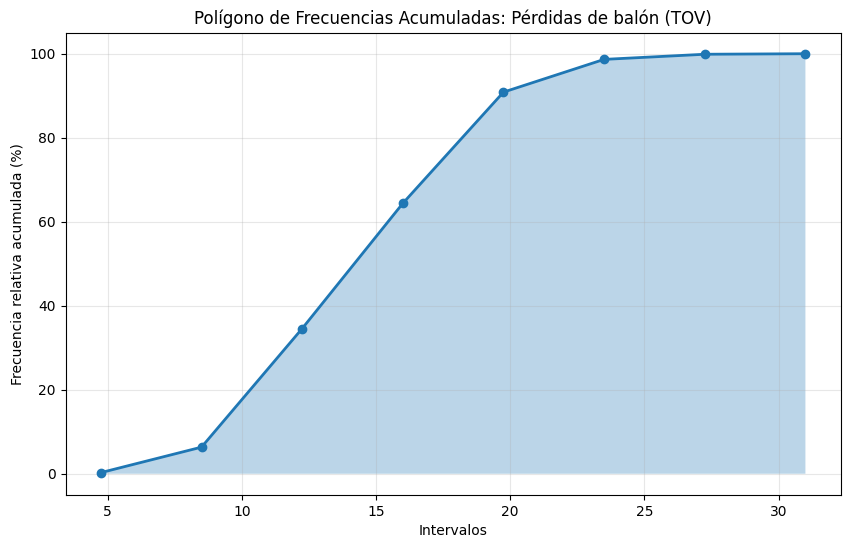

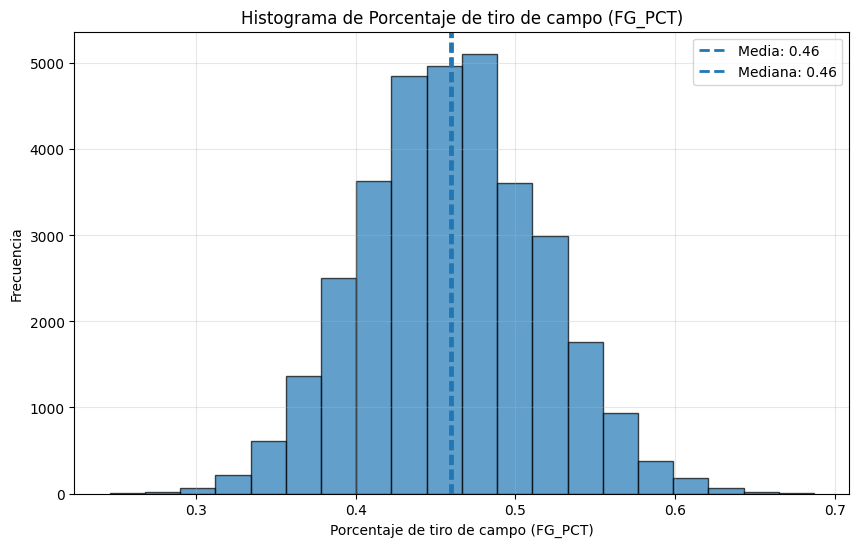

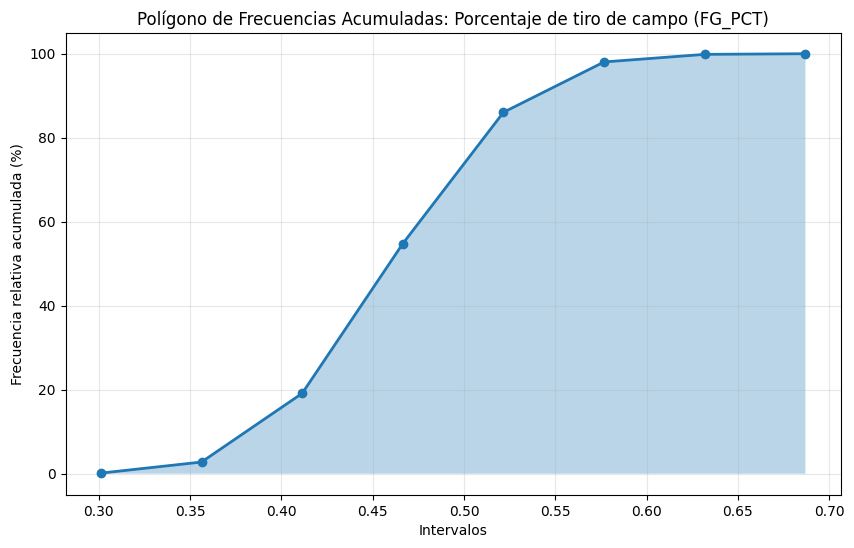

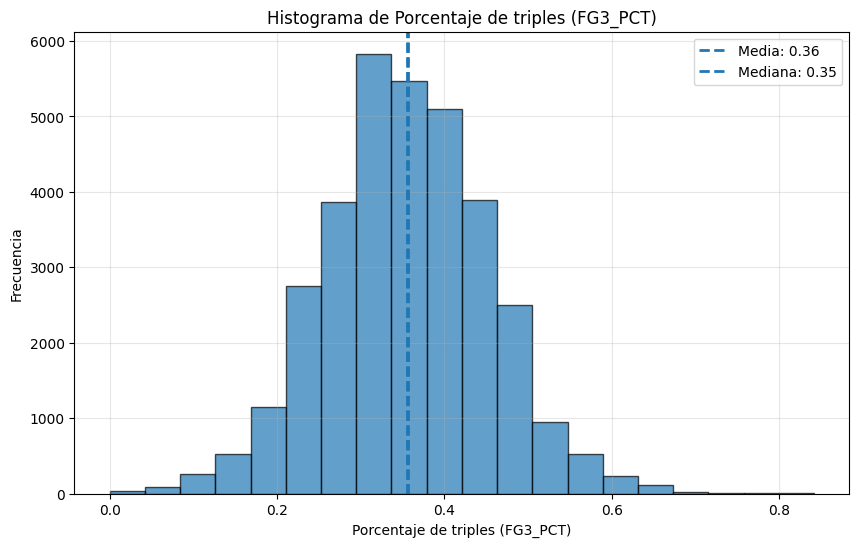

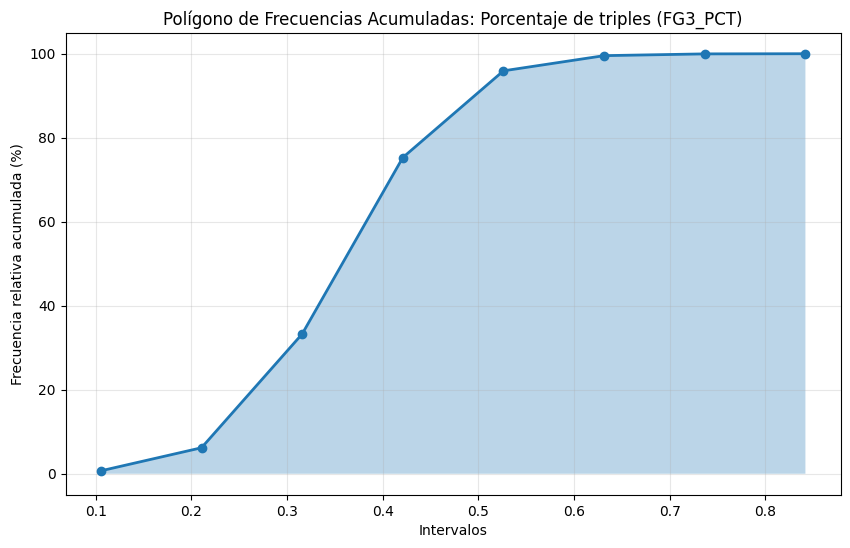

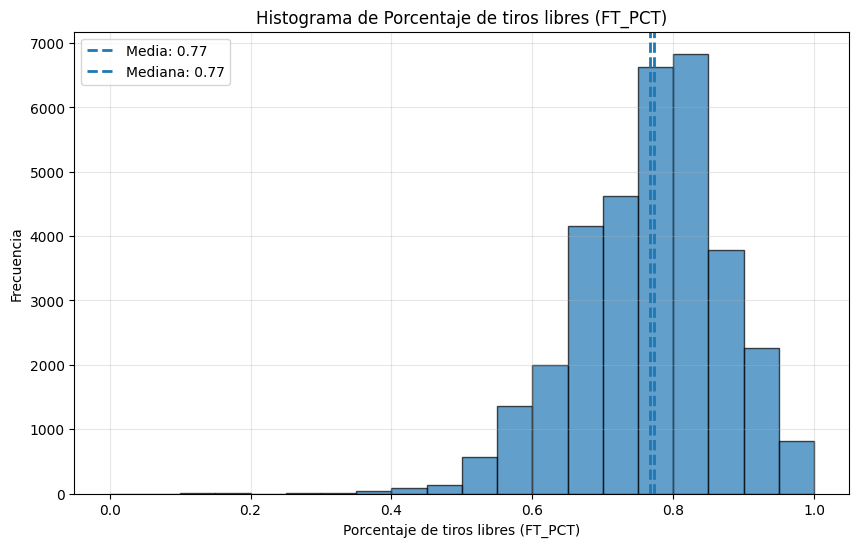

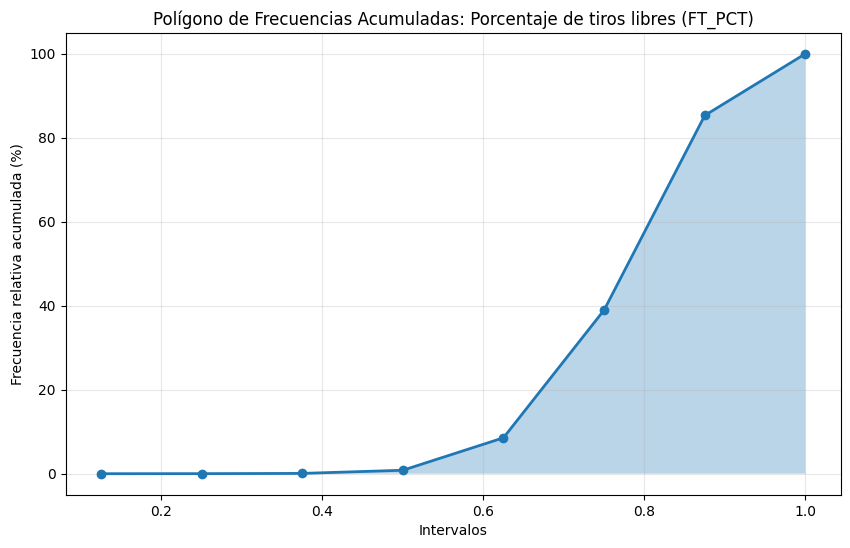

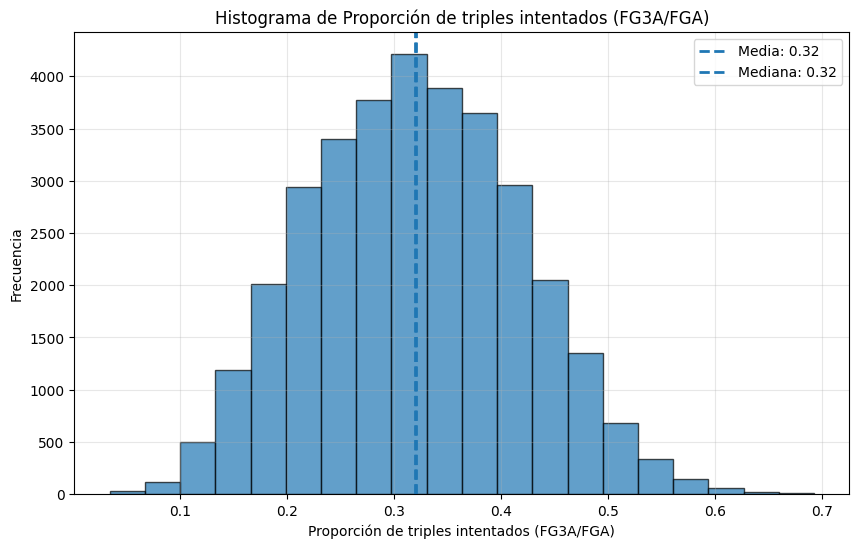

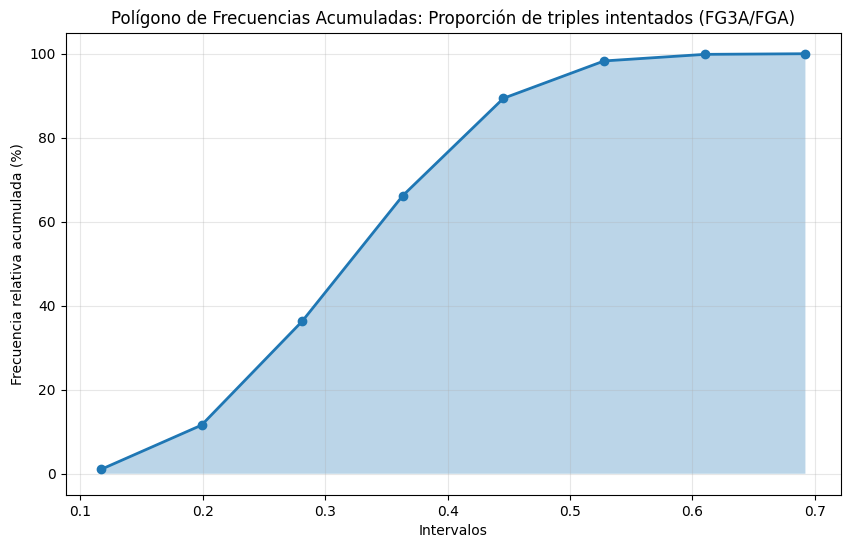

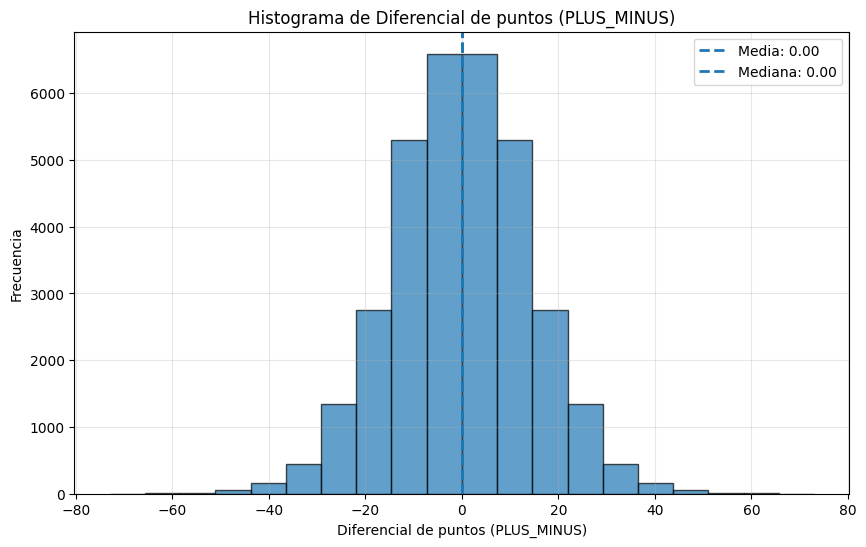

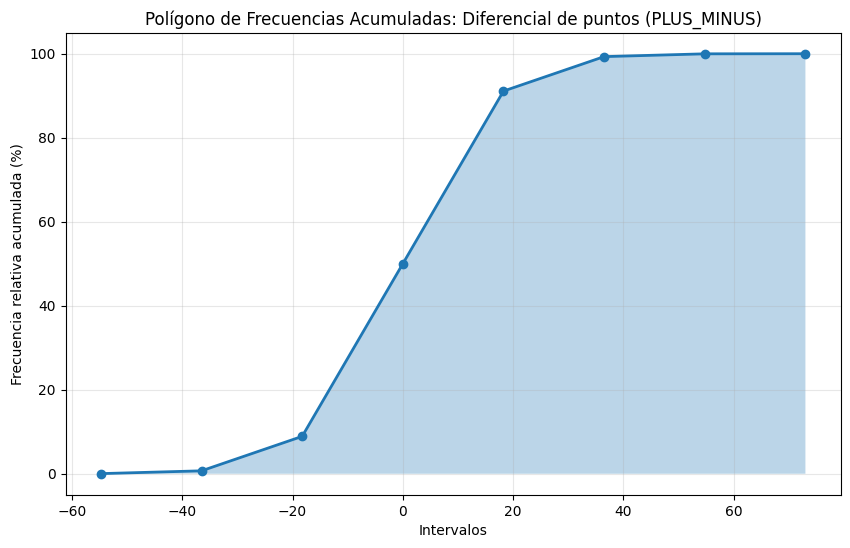

In [2]:
# ==========================================
# HISTOGRAMAS Y POLÍGONOS ACUMULADOS (EDA)
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import os

SAVE_IMAGES = True
IMAGE_DIR = "images"

if SAVE_IMAGES:
    os.makedirs(IMAGE_DIR, exist_ok=True)

# -------------------------------------------------
# Crear variable derivada FG3A/FGA si no existe
# -------------------------------------------------
if "FG3A_FGA" not in df.columns:
    df["FG3A_FGA"] = df["FG3A"] / df["FGA"]

# -------------------------------------------------
# Variables finales del análisis
# -------------------------------------------------
variables = {
    # -------------------------------
    # Cuantitativas discretas
    # -------------------------------
    "PTS": "Puntos totales (PTS)",
    "FG3M": "Triples anotados (FG3M)",
    "FG3A": "Triples intentados (FG3A)",
    "AST": "Asistencias (AST)",
    "REB": "Rebotes totales (REB)",
    "STL": "Robos de balón (STL)",
    "BLK": "Bloqueos (BLK)",
    "TOV": "Pérdidas de balón (TOV)",

    # -------------------------------
    # Cuantitativas continuas
    # -------------------------------
    "FG_PCT": "Porcentaje de tiro de campo (FG_PCT)",
    "FG3_PCT": "Porcentaje de triples (FG3_PCT)",
    "FT_PCT": "Porcentaje de tiros libres (FT_PCT)",
    "FG3A_FGA": "Proporción de triples intentados (FG3A/FGA)",
    "PLUS_MINUS": "Diferencial de puntos (PLUS_MINUS)"
}

# -------------------------------------------------
# Gráficos
# -------------------------------------------------
for var, label in variables.items():
    data = df[var].dropna()

    media = data.mean()
    mediana = data.median()

    # --------------------------------------
    # HISTOGRAMA
    # --------------------------------------
    plt.figure(figsize=(10, 6))
    plt.hist(
        data,
        bins=20,
        edgecolor="black",
        alpha=0.7
    )

    plt.axvline(
        media,
        linestyle="--",
        linewidth=2,
        label=f"Media: {media:.2f}"
    )
    plt.axvline(
        mediana,
        linestyle="--",
        linewidth=2,
        label=f"Mediana: {mediana:.2f}"
    )

    plt.xlabel(label)
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {label}")
    plt.legend()
    plt.grid(alpha=0.3)

    if SAVE_IMAGES:
        plt.savefig(
            f"{IMAGE_DIR}/histograma_{var.lower()}.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    # --------------------------------------
    # POLÍGONO DE FRECUENCIA ACUMULADA
    # --------------------------------------
    counts, bin_edges = np.histogram(data, bins=8)
    cumulative = np.cumsum(counts)
    cumulative_pct = cumulative / cumulative[-1] * 100

    plt.figure(figsize=(10, 6))
    plt.plot(
        bin_edges[1:],
        cumulative_pct,
        marker="o",
        linewidth=2
    )
    plt.fill_between(
        bin_edges[1:],
        cumulative_pct,
        alpha=0.3
    )

    plt.xlabel("Intervalos")
    plt.ylabel("Frecuencia relativa acumulada (%)")
    plt.title(f"Polígono de Frecuencias Acumuladas: {label}")
    plt.grid(alpha=0.3)

    if SAVE_IMAGES:
        plt.savefig(
            f"{IMAGE_DIR}/poligono_acumulado_{var.lower()}.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


Código para generar boxplots

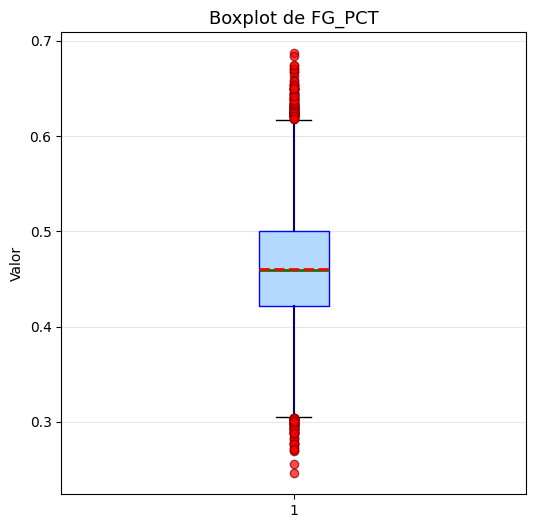

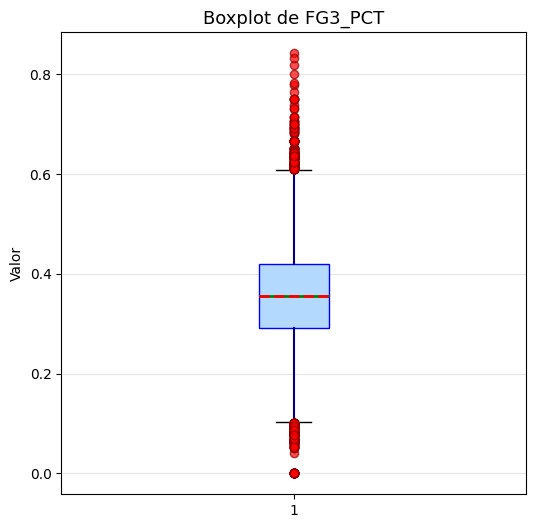

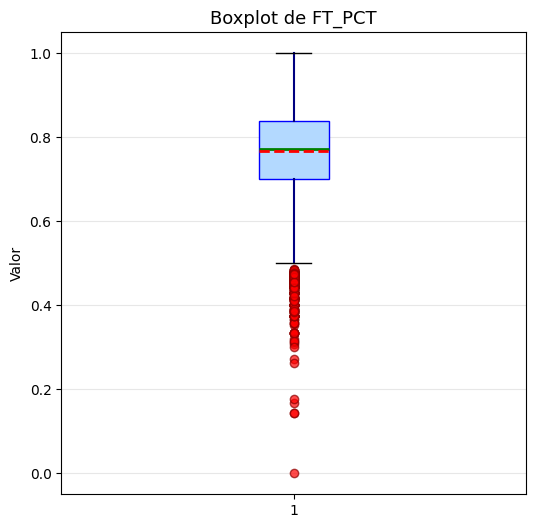

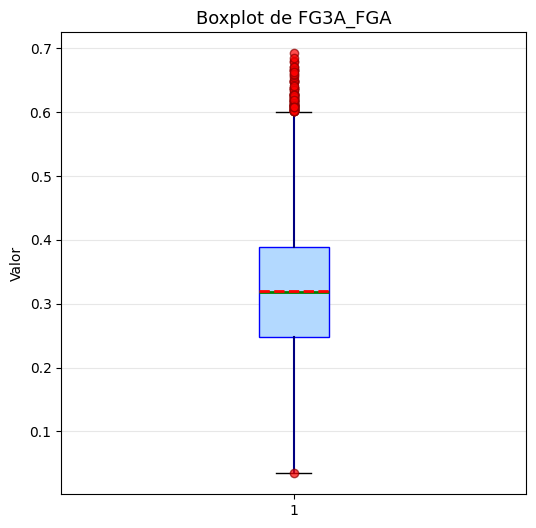

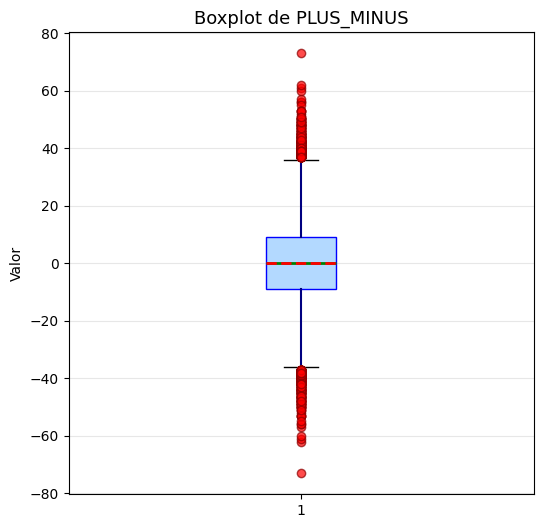

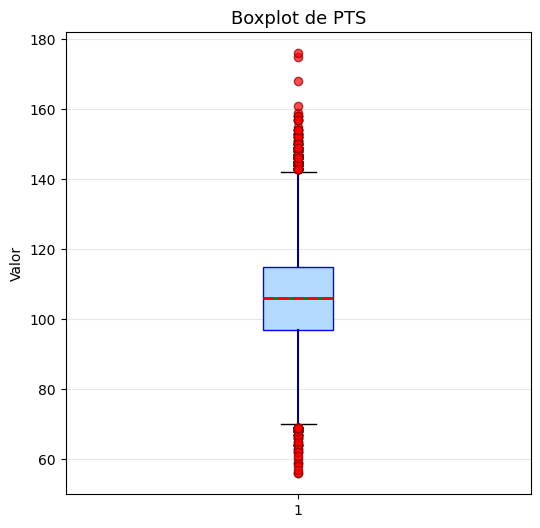

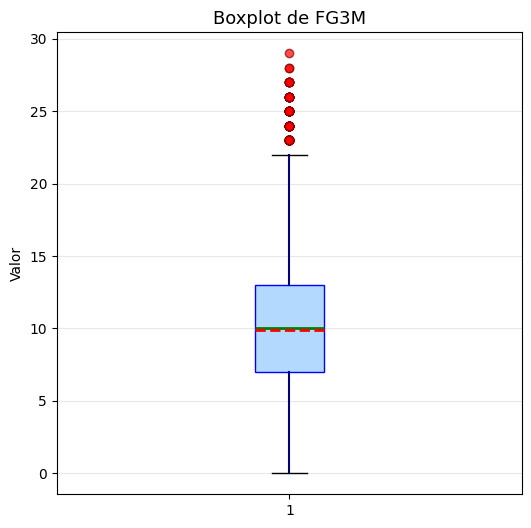

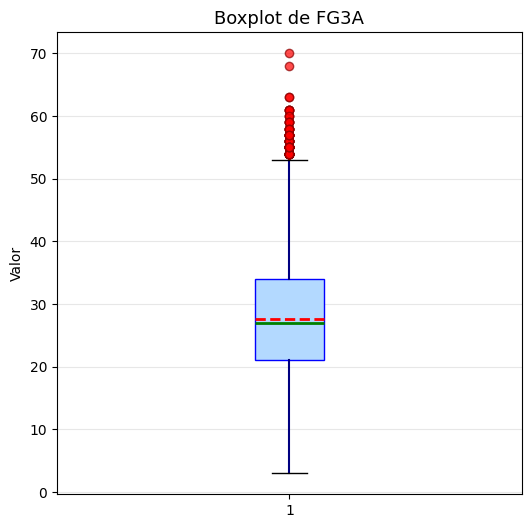

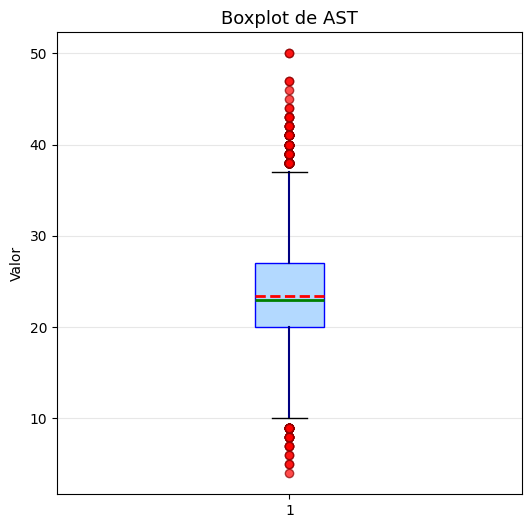

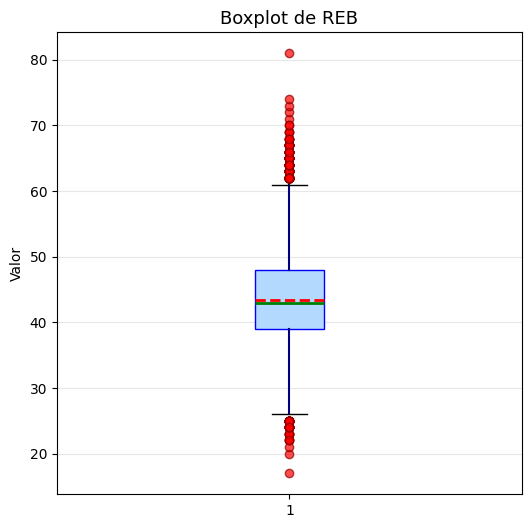

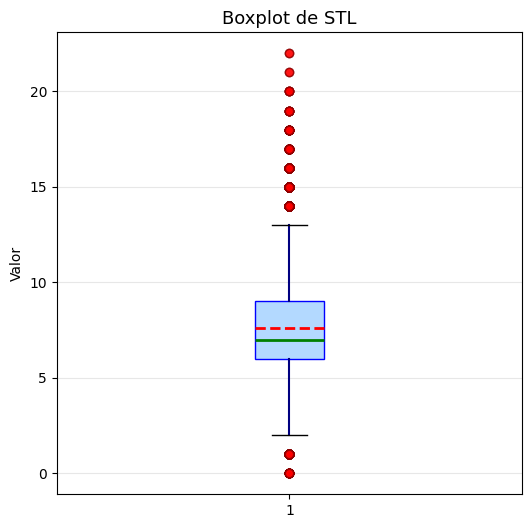

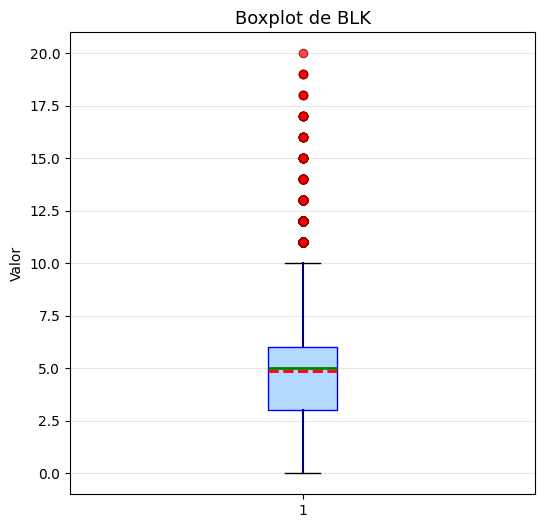

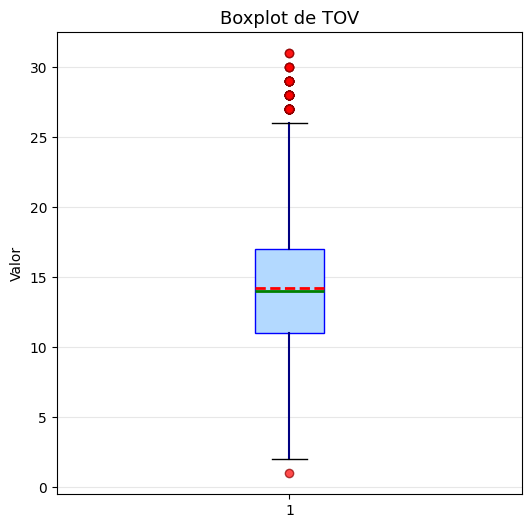

In [6]:
# ==========================================
# CELDA 3: BOXPLOTS INDIVIDUALES POR VARIABLE
# ==========================================

import os

# Crear variable razón (una sola vez)
df["FG3A_FGA"] = df["FG3A"] / df["FGA"]

# Crear carpeta para boxplots si no existe
BOXPLOT_DIR = "images/boxplots"
os.makedirs(BOXPLOT_DIR, exist_ok=True)

SAVE_IMAGES = True

# Lista de variables cuantitativas
variables_boxplot = [
    # Continuas
    "FG_PCT", "FG3_PCT", "FT_PCT", "FG3A_FGA", "PLUS_MINUS",
    # Discretas
    "PTS", "FG3M", "FG3A", "AST", "REB", "STL", "BLK", "TOV"
]

for var in variables_boxplot:
    data = df[var].dropna()

    plt.figure(figsize=(6, 6))

    box = plt.boxplot(
        data,
        vert=True,
        patch_artist=True,
        showmeans=True,
        meanline=True
    )

    # Caja
    box["boxes"][0].set_facecolor("#B3D9FF")
    box["boxes"][0].set_edgecolor("blue")

    # Bigotes
    for whisker in box["whiskers"]:
        whisker.set(color="navy", linewidth=1.5)

    # Mediana
    box["medians"][0].set(color="green", linewidth=2)

    # Media
    box["means"][0].set(color="red", linewidth=2)

    # Outliers
    for flier in box["fliers"]:
        flier.set(
            marker="o",
            markerfacecolor="red",
            markeredgecolor="darkred",
            alpha=0.7
        )

    plt.title(f"Boxplot de {var}", fontsize=13)
    plt.ylabel("Valor")
    plt.grid(axis="y", alpha=0.3)

    if SAVE_IMAGES:
        plt.savefig(
            f"{BOXPLOT_DIR}/boxplot_{var}.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


In [7]:
import pandas as pd
import numpy as np

variables_boxplot = [
    "FG_PCT", "FG3_PCT", "FT_PCT", "FG3A_FGA", "PLUS_MINUS",
    "PTS", "FG3M", "FG3A", "AST", "REB", "STL", "BLK", "TOV"
]

resumen_boxplot = []

for var in variables_boxplot:
    data = df[var].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data < lower_bound) | (data > upper_bound)]

    resumen_boxplot.append({
        "Variable": var,
        "Media": data.mean(),
        "Mediana": data.median(),
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Min_sin_outliers": data[data >= lower_bound].min(),
        "Max_sin_outliers": data[data <= upper_bound].max(),
        "N_outliers": outliers.count()
    })

df_boxplot_summary = pd.DataFrame(resumen_boxplot)

df_boxplot_summary


,Variable,Media,Mediana,Q1,Q3,IQR,Min_sin_outliers,Max_sin_outliers,N_outliers
0,FG_PCT,0.460423,0.459000,0.422000,0.500000,0.078000,0.305000,0.617,162
1,FG3_PCT,0.355998,0.355000,0.292000,0.419000,0.127000,0.103000,0.609,452
2,FT_PCT,0.766747,0.773000,0.700000,0.839000,0.139000,0.500000,1.000,275
3,FG3A_FGA,0.320092,0.319149,0.247191,0.388889,0.141698,0.035294,0.600,69
4,PLUS_MINUS,0.000000,0.000000,-9.000000,9.000000,18.000000,-36.000000,36.000,460
5,PTS,106.039531,106.000000,97.000000,115.000000,18.000000,70.000000,142.000,231
6,FG3M,9.869852,10.000000,7.000000,13.000000,6.000000,0.000000,22.000,140
7,FG3A,27.547034,27.000000,21.000000,34.000000,13.000000,3.000000,53.000,98
8,AST,23.383870,23.000000,20.000000,27.000000,7.000000,10.000000,37.000,260
9,REB,43.443871,43.000000,39.000000,48.000000,9.000000,26.000000,61.000,229


Código para ver gráficos de asimetría y curtosis

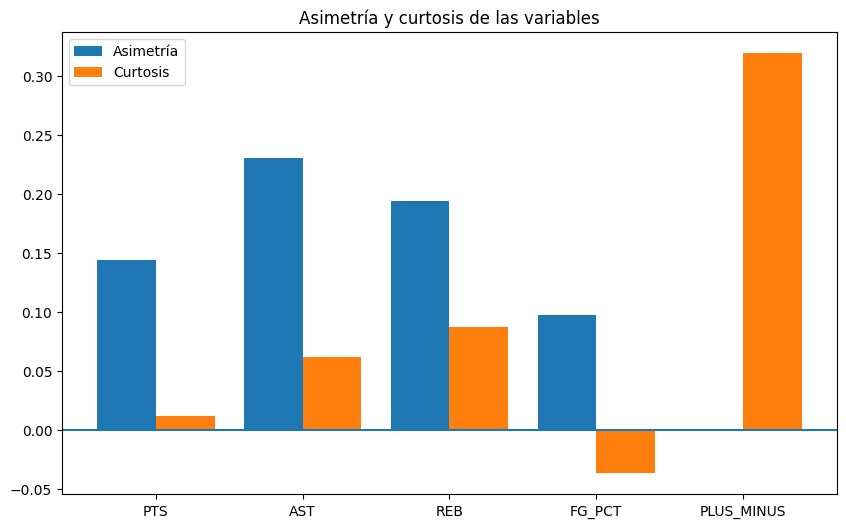

In [15]:
# ==========================================
# ASIMETRÍA Y CURTOSIS
# ==========================================

from scipy.stats import skew, kurtosis

skewness = []
kurt = []

for var in variables.keys():
    data = df[var].dropna()
    skewness.append(skew(data))
    kurt.append(kurtosis(data))  # exceso de curtosis

x = np.arange(len(variables))

plt.figure(figsize=(10, 6))
plt.bar(x - 0.2, skewness, width=0.4, label="Asimetría")
plt.bar(x + 0.2, kurt, width=0.4, label="Curtosis")

plt.xticks(x, variables.keys())
plt.axhline(0)
plt.legend()
plt.title("Asimetría y curtosis de las variables")

if SAVE_IMAGES:
    plt.savefig(f"{IMAGE_DIR}/asimetria_curtosis.png",
                dpi=300, bbox_inches="tight")

plt.show()


Código para generar la matriz de correlación y la tabla de outliers de las variables principales a analizar

In [18]:
# =====================================================
#  - Matriz de correlación
#  - Outliers (método IQR)
# =====================================================

import pandas as pd
import numpy as np
import os

# ----------------------
# CONFIGURACIÓN
# ----------------------
EXPORT_TEX = True          # True -> genera .tex | False -> solo muestra tablas
TEX_DIR = "latex_tables"

if EXPORT_TEX:
    os.makedirs(TEX_DIR, exist_ok=True)

# ----------------------
# VARIABLES ANALIZADAS
# ----------------------
variables = ["PTS", "REB", "AST", "FG_PCT", "PLUS_MINUS"]

# =====================================================
# 1) MATRIZ DE CORRELACIÓN
# =====================================================
corr_matrix = df[variables].corr().round(4)

print("Matriz de correlación:")
display(corr_matrix)

if EXPORT_TEX:
    corr_latex = corr_matrix.to_latex(
        caption="Matriz de correlación entre variables principales",
        label="tab:correlacion",
        column_format="l" + "c" * len(variables),
        bold_rows=True
    )

    with open(f"{TEX_DIR}/matriz_correlacion.tex", "w", encoding="utf-8") as f:
        f.write(corr_latex)

# =====================================================
# 2) OUTLIERS — MÉTODO IQR
# =====================================================
def outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(series), len(outliers), round(len(outliers)/len(series)*100, 2), round(lower,2), round(upper,2)

outlier_data = []

for var in ["PTS", "REB", "AST", "PLUS_MINUS"]:
    total, n_out, pct, low, up = outliers_iqr(df[var].dropna())
    outlier_data.append([var, total, n_out, pct, low, up])

outliers_df = pd.DataFrame(
    outlier_data,
    columns=["Variable", "Total", "Outliers", "%", "Límite Inf.", "Límite Sup."]
)

print("Tabla de outliers (IQR):")
display(outliers_df)

if EXPORT_TEX:
    outliers_latex = outliers_df.to_latex(
        index=False,
        caption="Detección de outliers usando el método IQR",
        label="tab:outliers_iqr",
        column_format="lccccc"
    )

    with open(f"{TEX_DIR}/tabla_outliers.tex", "w", encoding="utf-8") as f:
        f.write(outliers_latex)


Matriz de correlación:


,PTS,REB,AST,FG_PCT,PLUS_MINUS
PTS,1.0000,0.1497,0.6186,0.6855,0.5215
REB,0.1497,1.0000,0.0516,-0.1707,0.3402
AST,0.6186,0.0516,1.0000,0.5591,0.3962
FG_PCT,0.6855,-0.1707,0.5591,1.0000,0.5469
PLUS_MINUS,0.5215,0.3402,0.3962,0.5469,1.0000


Tabla de outliers (IQR):


,Variable,Total,Outliers,%,Límite Inf.,Límite Sup.
0,PTS,33316,231,0.69,70.0,142.0
1,REB,33316,229,0.69,25.5,61.5
2,AST,33316,260,0.78,9.5,37.5
3,PLUS_MINUS,33316,460,1.38,-36.0,36.0


Iniciando con la preparacion del Dataset para hacer las pruebas necesarias, inicialmente se va a analizar el dataset para ver si hay datos faltantes

In [23]:
# ==========================================
# ANÁLISIS DE VALORES FALTANTES (SECCIÓN 3.3)
# ==========================================

import os

# --------------------------------------------------
# CONFIGURACIÓN
# --------------------------------------------------
EXPORT_TEX = True                  # True -> genera .tex | False -> solo muestra tabla
TEX_DIR = "latex_tables"
TEX_FILENAME = "valores_faltantes.tex"

if EXPORT_TEX:
    os.makedirs(TEX_DIR, exist_ok=True)

# --------------------------------------------------
# VARIABLES ANALIZADAS
# --------------------------------------------------
variables_prep = ["PTS", "REB", "AST", "FG_PCT", "PLUS_MINUS"]

# --------------------------------------------------
# CÁLCULO DE VALORES FALTANTES
# --------------------------------------------------
total_obs = len(df)
na_info = []

for var in variables_prep:
    n_na = df[var].isna().sum()
    pct_na = round(n_na / total_obs * 100, 3)

    tratamiento = (
        "Imputación por mediana" if n_na > 0 else "No requiere tratamiento"
    )

    na_info.append([var, n_na, pct_na, tratamiento])

tabla_na = pd.DataFrame(
    na_info,
    columns=[
        "Variable",
        "Valores Faltantes",
        "Porcentaje (%)",
        "Tratamiento Aplicado"
    ]
)

# --------------------------------------------------
# MOSTRAR TABLA
# --------------------------------------------------
print("Tabla de valores faltantes:")
display(tabla_na)

# --------------------------------------------------
# EXPORTACIÓN A LaTeX (OPCIONAL)
# --------------------------------------------------
if EXPORT_TEX:
    latex_table = tabla_na.to_latex(
        index=False,
        caption="Tratamiento de valores faltantes en las variables analizadas",
        label="tab:valores_faltantes",
        column_format="lccc"
    )

    tex_path = os.path.join(TEX_DIR, TEX_FILENAME)

    with open(tex_path, "w", encoding="utf-8") as f:
        f.write(latex_table)

    print(f"✔ Archivo LaTeX generado: {tex_path}")


Tabla de valores faltantes:


,Variable,Valores Faltantes,Porcentaje (%),Tratamiento Aplicado
0,PTS,0,0.0,No requiere tratamiento
1,REB,0,0.0,No requiere tratamiento
2,AST,0,0.0,No requiere tratamiento
3,FG_PCT,0,0.0,No requiere tratamiento
4,PLUS_MINUS,0,0.0,No requiere tratamiento


✔ Archivo LaTeX generado: latex_tables\valores_faltantes.tex


Preparación de los datos y ejecución de pruebas de regresión logística para responder a la pregunta 1

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ===============================
# CARGA Y PREPARACIÓN DE DATOS
# ===============================
# df = pd.read_csv("nba_2010_2024.csv")
data = df.copy()
data["WL_bin"] = data["WL"].map({"W": 1, "L": 0})

vars_model = ["FG3M", "FG_PCT", "WL_bin"]
data_model = data[vars_model].dropna()

# ===============================
# SPEARMAN
# ===============================
corr_spearman, p_value = spearmanr(
    data_model["FG3M"], data_model["FG_PCT"]
)

# ===============================
# VIF
# ===============================
X_vif = sm.add_constant(data_model[["FG3M", "FG_PCT"]])
vif_df = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# ===============================
# MODELO LOGÍSTICO
# ===============================
X = sm.add_constant(data_model[["FG3M", "FG_PCT"]])
y = data_model["WL_bin"]

logit_model = sm.Logit(y, X)
result = logit_model.fit()

# ===============================
# TABLA DE COEFICIENTES
# ===============================
coef_df = pd.DataFrame({
    "Coeficiente": result.params,
    "Std.Error": result.bse,
    "z": result.tvalues,
    "p-value": result.pvalues
})

# ===============================
# ODDS RATIOS
# ===============================
conf = result.conf_int()
or_df = pd.DataFrame({
    "OR": np.exp(result.params),
    "CI 2.5\\%": np.exp(conf[0]),
    "CI 97.5\\%": np.exp(conf[1])
})

# ===============================
# MÉTRICAS DEL MODELO
# ===============================
metrics_df = pd.DataFrame({
    "Métrica": [
        "Pseudo $R^2$ (McFadden)",
        "Log-Likelihood",
        "AIC",
        "N Observaciones"
    ],
    "Valor": [
        result.prsquared,
        result.llf,
        result.aic,
        int(result.nobs)
    ]
})

# ===============================
# EXPORTAR A LaTeX
# ===============================
output_dir = "latex_tables"
os.makedirs(output_dir, exist_ok=True)  # Crea la carpeta si no existe

file_path = os.path.join(output_dir, "resultados_logit.tex")

with open(file_path, "w", encoding="utf-8") as f:

    f.write("\\section{Resultados del Modelo Logístico}\n\n")

    f.write("\\subsection{Correlación de Spearman}\n")
    f.write(
        f"La correlación de Spearman entre FG3M y FG\\_PCT fue "
        f"$\\rho = {corr_spearman:.3f}$ con un valor-p de "
        f"$p = {p_value:.4f}$.\n\n"
    )

    f.write("\\subsection{Multicolinealidad (VIF)}\n")
    f.write(vif_df.to_latex(
        index=False,
        float_format="%.3f",
        caption="Factores de Inflación de la Varianza (VIF)",
        label="tab:vif"
    ))
    f.write("\n\n")

    f.write("\\subsection{Regresión Logística}\n")
    f.write(coef_df.to_latex(
        float_format="%.4f",
        caption="Coeficientes del modelo Logit",
        label="tab:logit_coef"
    ))
    f.write("\n\n")

    f.write("\\subsection{Odds Ratios}\n")
    f.write(or_df.to_latex(
        float_format="%.4f",
        caption="Odds Ratios e intervalos de confianza al 95\\%",
        label="tab:odds_ratios"
    ))
    f.write("\n\n")

    f.write("\\subsection{Calidad del Modelo}\n")
    f.write(metrics_df.to_latex(
        index=False,
        float_format="%.4f",
        caption="Métricas de ajuste del modelo",
        label="tab:metricas"
    ))

print("Archivo 'resultados_logit.tex' generado correctamente.")


Optimization terminated successfully.
         Current function value: 0.576483
         Iterations 6
Archivo 'resultados_logit.tex' generado correctamente.


Preparación de los datos y ejecución de la prueba de Mann-Whitney

In [7]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# ===============================
# CARGA Y PREPARACIÓN DE DATOS
# ===============================
# df = pd.read_csv("nba_2010_2024.csv")

data = df.copy()

# Variable respuesta categórica
data = data[["WL", "FG3M"]].dropna()

# Separación de grupos independientes
fg3m_win = data.loc[data["WL"] == "W", "FG3M"]
fg3m_loss = data.loc[data["WL"] == "L", "FG3M"]

# ===============================
# TAMAÑOS MUESTRALES
# ===============================
n_win = fg3m_win.shape[0]
n_loss = fg3m_loss.shape[0]

# ===============================
# ESTADÍSTICOS DESCRIPTIVOS
# ===============================
desc_df = pd.DataFrame({
    "Grupo": ["Victorias", "Derrotas"],
    "N": [n_win, n_loss],
    "Mediana_FG3M": [
        fg3m_win.median(),
        fg3m_loss.median()
    ],
    "Q1": [
        fg3m_win.quantile(0.25),
        fg3m_loss.quantile(0.25)
    ],
    "Q3": [
        fg3m_win.quantile(0.75),
        fg3m_loss.quantile(0.75)
    ]
})

# ===============================
# PRUEBA MANN–WHITNEY U
# ===============================
u_stat, p_value = mannwhitneyu(
    fg3m_win,
    fg3m_loss,
    alternative="two-sided"
)

# ===============================
# TAMAÑO DEL EFECTO (r)
# ===============================
# r = Z / sqrt(N)
# Aproximación normal
mean_u = n_win * n_loss / 2
std_u = np.sqrt(n_win * n_loss * (n_win + n_loss + 1) / 12)

z_value = (u_stat - mean_u) / std_u
effect_size_r = abs(z_value) / np.sqrt(n_win + n_loss)

mw_results_df = pd.DataFrame({
    "U_statistic": [u_stat],
    "Z_value": [z_value],
    "p_value": [p_value],
    "Effect_size_r": [effect_size_r]
})

# ===============================
# EXPORTACIÓN A LaTeX
# ===============================

# ===============================
# EXPORTAR A LaTeX
# ===============================
output_dir = "latex_tables"
os.makedirs(output_dir, exist_ok=True)  # Crea la carpeta si no existe

file_path = os.path.join(output_dir, "resultados_mann_whitney.tex")

with open(file_path,"w") as f:

    f.write("\\subsection{Prueba de Mann--Whitney U para FG3M}\n\n")

    f.write("\\subsubsection{Preparación de los datos y estadísticos descriptivos}\n")
    f.write(desc_df.to_latex(index=False, float_format="%.3f"))
    f.write("\n\n")

    f.write("\\subsubsection{Resultados de la prueba de Mann--Whitney U}\n")
    f.write(mw_results_df.to_latex(index=False, float_format="%.4f"))
    f.write("\n\n")

    f.write("\\subsubsection{Interpretación del tamaño del efecto}\n")
    f.write(
        "El tamaño del efecto se calculó mediante la estadística "
        "$r = |Z|/\\sqrt{N}$, donde valores aproximados de 0.1 indican "
        "efectos pequeños, 0.3 efectos moderados y 0.5 efectos grandes."
    )

print("Archivo 'resultados_mann_whitney.tex' generado correctamente.")


Archivo 'resultados_mann_whitney.tex' generado correctamente.


A continuación se preparan los datos y se ejecuta la prueba de ANOVA para responder a la pregunta 2

In [8]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ===============================
# CREAR CARPETA PARA LATEX
# ===============================
LATEX_DIR = "latex_tables"
os.makedirs(LATEX_DIR, exist_ok=True)

# ===============================
# PREPARACIÓN DE DATOS
# ===============================
# Copia de trabajo
data = df.copy()

# Variable de proporción
data["FG3A_FGA"] = data["FG3A"] / data["FGA"]

# Selección de variables relevantes
anova_vars = ["SEASON_YEAR", "PTS", "FG3A_FGA"]
data_anova = data[anova_vars].dropna()

# Tratar SEASON_YEAR como factor
data_anova["SEASON_YEAR"] = data_anova["SEASON_YEAR"].astype(str)

# ===============================
# ESTADÍSTICOS DESCRIPTIVOS POR TEMPORADA
# ===============================
desc_pts = data_anova.groupby("SEASON_YEAR")["PTS"].agg(
    mean="mean", std="std", n="count"
)

desc_fg3 = data_anova.groupby("SEASON_YEAR")["FG3A_FGA"].agg(
    mean="mean", std="std", n="count"
)

# Exportar descriptivos
desc_pts.to_latex(
    f"{LATEX_DIR}/anova_descriptivos_pts.tex",
    float_format="%.3f",
    caption="Estadísticos descriptivos de PTS por temporada",
    label="tab:anova-desc-pts"
)

desc_fg3.to_latex(
    f"{LATEX_DIR}/anova_descriptivos_fg3a_fga.tex",
    float_format="%.3f",
    caption="Estadísticos descriptivos de FG3A/FGA por temporada",
    label="tab:anova-desc-fg3"
)

# ===============================
# ANOVA PARA PTS
# ===============================
model_pts = ols("PTS ~ C(SEASON_YEAR)", data=data_anova).fit()
anova_pts = sm.stats.anova_lm(model_pts, typ=2)

anova_pts.to_latex(
    f"{LATEX_DIR}/anova_pts.tex",
    float_format="%.4f",
    caption="ANOVA de una vía para PTS por temporada",
    label="tab:anova-pts"
)

# ===============================
# ANOVA PARA FG3A/FGA
# ===============================
model_fg3 = ols("FG3A_FGA ~ C(SEASON_YEAR)", data=data_anova).fit()
anova_fg3 = sm.stats.anova_lm(model_fg3, typ=2)

anova_fg3.to_latex(
    f"{LATEX_DIR}/anova_fg3a_fga.tex",
    float_format="%.4f",
    caption="ANOVA de una vía para FG3A/FGA por temporada",
    label="tab:anova-fg3"
)

# ===============================
# VERIFICACIÓN DE SUPUESTOS
# ===============================

# --- Normalidad de residuos (Shapiro-Wilk sobre una muestra)
resid_pts = model_pts.resid.sample(5000, random_state=42)
resid_fg3 = model_fg3.resid.sample(5000, random_state=42)

shapiro_pts = stats.shapiro(resid_pts)
shapiro_fg3 = stats.shapiro(resid_fg3)

# --- Homogeneidad de varianzas (Levene)
groups_pts = [
    g["PTS"].values
    for _, g in data_anova.groupby("SEASON_YEAR")
]

groups_fg3 = [
    g["FG3A_FGA"].values
    for _, g in data_anova.groupby("SEASON_YEAR")
]

levene_pts = stats.levene(*groups_pts)
levene_fg3 = stats.levene(*groups_fg3)

# ===============================
# TABLA DE SUPUESTOS
# ===============================
supuestos_df = pd.DataFrame({
    "Variable": ["PTS", "FG3A/FGA"],
    "Shapiro_W": [shapiro_pts.statistic, shapiro_fg3.statistic],
    "Shapiro_p": [shapiro_pts.pvalue, shapiro_fg3.pvalue],
    "Levene_W": [levene_pts.statistic, levene_fg3.statistic],
    "Levene_p": [levene_pts.pvalue, levene_fg3.pvalue]
})

supuestos_df.to_latex(
    f"{LATEX_DIR}/anova_supuestos.tex",
    index=False,
    float_format="%.4f",
    caption="Evaluación de supuestos del ANOVA",
    label="tab:anova-supuestos"
)

print("ANOVA y tablas LaTeX generadas en la carpeta:", LATEX_DIR)


ANOVA y tablas LaTeX generadas en la carpeta: latex_tables


In [3]:
# ===========================================
# PREGUNTA 2: ANOVA POR TEMPORADA
# ===========================================
# Objetivo: Verificar si las diferencias de PTS y proporción de triples
# entre temporadas son estadísticamente significativas
# Usando exclusivamente datos reales del dataset NBA

import pandas as pd
from scipy import stats
import os

# -------------------------------------------
# Cargar dataset real
# -------------------------------------------
FILE_NAME = 'nba_2010_2024_preprocesado_completo.csv'

if not os.path.exists(FILE_NAME):
    raise FileNotFoundError(f"No se encontró el archivo: {FILE_NAME}")

df = pd.read_csv(FILE_NAME)

# -------------------------------------------
# Comprobación de columnas necesarias
# -------------------------------------------
columnas_necesarias = ['SEASON_YEAR', 'PTS', 'FG3A', 'FGA']
faltantes = [c for c in columnas_necesarias if c not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas necesarias en el CSV: {faltantes}")

# -------------------------------------------
# Variables derivadas
# -------------------------------------------
df['FG3A_RATIO'] = df['FG3A'] / df['FGA']

# -------------------------------------------
# Medias descriptivas por temporada
# -------------------------------------------
temporadas = (
    df.groupby('SEASON_YEAR')
      .agg({
          'PTS': 'mean',
          'FG3A_RATIO': 'mean'
      })
      .reset_index()
)

print("=" * 60)
print("MEDIAS POR TEMPORADA")
print("=" * 60)
print(temporadas.to_string(index=False))

# ==========================================
# ANOVA: Puntos por Partido (PTS)
# ==========================================
grupos_pts = [
    grupo['PTS'].dropna().values
    for _, grupo in df.groupby('SEASON_YEAR')
]

f_pts, p_pts = stats.f_oneway(*grupos_pts)

print("\n" + "=" * 60)
print("ANOVA: PUNTOS POR PARTIDO (PTS)")
print("=" * 60)
print(f"Estadístico F: {f_pts:.4f}")
print(f"Valor p: {p_pts:.2e}")
print(f"Significativo (α=0.05): {'Sí' if p_pts < 0.05 else 'No'}")

# ==========================================
# ANOVA: Proporción de Triples (FG3A/FGA)
# ==========================================
grupos_fg3 = [
    grupo['FG3A_RATIO'].dropna().values
    for _, grupo in df.groupby('SEASON_YEAR')
]

f_fg3, p_fg3 = stats.f_oneway(*grupos_fg3)

print("\n" + "=" * 60)
print("ANOVA: PROPORCIÓN DE TRIPLES (FG3A/FGA)")
print("=" * 60)
print(f"Estadístico F: {f_fg3:.4f}")
print(f"Valor p: {p_fg3:.2e}")
print(f"Significativo (α=0.05): {'Sí' if p_fg3 < 0.05 else 'No'}")


MEDIAS POR TEMPORADA
SEASON_YEAR       PTS  FG3A_RATIO
    2010-11 -0.477615    0.222135
    2011-12 -0.719827    0.226304
    2012-13 -0.581578    0.243928
    2013-14 -0.370264    0.260029
    2014-15 -0.443477    0.268483
    2015-16 -0.247892    0.285100
    2016-17 -0.033039    0.316778
    2017-18  0.021625    0.337869
    2018-19  0.380451    0.359177
    2019-20  0.423832    0.384487
    2020-21  0.445418    0.392786
    2021-22  0.336829    0.400175
    2022-23  0.636385    0.388301
    2023-24  0.601468    0.395183

ANOVA: PUNTOS POR PARTIDO (PTS)
Estadístico F: 647.8556
Valor p: 0.00e+00
Significativo (α=0.05): Sí

ANOVA: PROPORCIÓN DE TRIPLES (FG3A/FGA)
Estadístico F: 1950.5527
Valor p: 0.00e+00
Significativo (α=0.05): Sí


El siguiente codigo ejecuta la prueba de regresión lineal para complementar los resultados de anova en la pregunta 3

In [11]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan

# ===============================
# CREAR CARPETA PARA TABLAS LaTeX
# ===============================
output_dir = "latex_tables"
os.makedirs(output_dir, exist_ok=True)

# ===============================
# CARGA DE DATOS
# ===============================
# df = pd.read_csv("nba_2010_2024.csv")
data = df.copy()

# ===============================
# PREPARACIÓN DE VARIABLES
# ===============================

# 1️⃣ Variable temporal ordinal (orden cronológico)
season_order = sorted(data["SEASON_YEAR"].unique())
season_map = {season: i for i, season in enumerate(season_order)}
data["season_num"] = data["SEASON_YEAR"].map(season_map)

# 2️⃣ Proporción de triples intentados
data["FG3_ratio"] = data["FG3A"] / data["FGA"]

# 3️⃣ Selección final de variables
reg_data = data[["season_num", "PTS", "FG3_ratio"]].dropna()

# ===============================
# FUNCIÓN: REGRESIÓN LINEAL SIMPLE
# ===============================
def run_linear_regression(y_var, df, label):

    # Matriz de diseño
    X = sm.add_constant(df["season_num"])
    y = df[y_var]

    # Ajuste del modelo
    model = sm.OLS(y, X).fit()

    # ===============================
    # EVALUACIÓN DE SUPUESTOS
    # ===============================

    residuals = model.resid

    # Normalidad (submuestra por tamaño muestral grande)
    shapiro_w, shapiro_p = shapiro(
        residuals.sample(5000, random_state=1)
    )

    # Homocedasticidad
    bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X)

    # ===============================
    # EXPORTAR RESULTADOS A LaTeX
    # ===============================
    tex_path = os.path.join(output_dir, f"regression_{label}.tex")

    with open(tex_path, "w", encoding="utf-8") as f:

        f.write(f"\\subsection{{Regresión lineal: {y_var}}}\n\n")

        # Resultados del modelo
        f.write("\\subsubsection{Resultados del modelo}\n")
        f.write(model.summary().as_latex())

        # Evaluación de supuestos
        f.write("\n\\subsubsection{Evaluación de supuestos}\n")
        f.write("\\begin{table}[H]\n\\centering\n")
        f.write("\\begin{tabular}{lcc}\n")
        f.write("\\toprule\n")
        f.write("Prueba & Estadístico & p-valor \\\\\n")
        f.write("\\midrule\n")
        f.write(f"Shapiro--Wilk & {shapiro_w:.4f} & {shapiro_p:.4f} \\\\\n")
        f.write(f"Breusch--Pagan & {bp_stat:.4f} & {bp_p:.4f} \\\\\n")
        f.write("\\bottomrule\n")
        f.write("\\end{tabular}\n")
        f.write(
            f"\\caption{{Evaluación de supuestos para la regresión de {y_var}}}\n"
        )
        f.write("\\end{table}\n")

    return model

# ===============================
# EJECUCIÓN DE REGRESIONES (PREGUNTA 2)
# ===============================
model_pts = run_linear_regression("PTS", reg_data, "pts")
model_fg3 = run_linear_regression("FG3_ratio", reg_data, "fg3_ratio")

print("Regresiones lineales ejecutadas y exportadas a LaTeX correctamente.")


Regresiones lineales ejecutadas y exportadas a LaTeX correctamente.


El código siguiente responde a la prueba de regresión múltiple para responder a la pregunta 3

In [4]:
# ===========================================
# PREGUNTA 3: REGRESIÓN MÚLTIPLE
# ===========================================
# Genera: generated/pregunta3.tex

import pandas as pd
import numpy as np
from scipy import stats
import os

FILE_NAME = 'nba_2010_2024_preprocesado_completo.csv'

df = pd.read_csv(FILE_NAME)
  
# Predictores y variable dependiente
predictores = ['AST', 'REB', 'STL', 'TOV', 'FG_PCT']
X = df[predictores].dropna()
y = df.loc[X.index, 'PLUS_MINUS']

# Matriz de diseño con intercepto
X_mat = np.column_stack([np.ones(len(X)), X.values])

# Coeficientes usando pseudo-inversa para robustez
XtX_inv = np.linalg.pinv(X_mat.T @ X_mat)
beta = XtX_inv @ X_mat.T @ y.values

# Predicciones y residuos
y_pred = X_mat @ beta
residuos = y.values - y_pred
n_obs, k = len(y), len(predictores)

# Estadísticas R²
ss_res = np.sum(residuos**2)
ss_tot = np.sum((y.values - y.mean())**2)
r2 = 1 - ss_res/ss_tot
r2_adj = 1 - (1-r2)*(n_obs-1)/(n_obs-k-1)

# Error estándar de los coeficientes
mse = ss_res / (n_obs - k - 1)
se_beta = np.sqrt(np.diag(XtX_inv) * mse)

# Estadísticos t y p-values
t_stats = beta / se_beta
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), n_obs - k - 1))

# Estadístico F global
f_stat = (r2 / k) / ((1 - r2) / (n_obs - k - 1))

# Mostrar resultados
print("\n===== Resultados de la Regresión Múltiple =====")
print(f"R² = {r2:.4f}")
print(f"R² ajustado = {r2_adj:.4f}")
print(f"F-statistic = {f_stat:.3f} (gl_modelo={k}, gl_residuo={n_obs-k-1})\n")

print("Coeficientes:")
print(f"{'Variable':<10} {'Beta':>8} {'SE':>8} {'t':>8} {'p-value':>10}")
print("-"*50)
print(f"{'Intercept':<10} {beta[0]:>8.3f} {se_beta[0]:>8.3f} {t_stats[0]:>8.2f} {p_values[0]:>10.3g}")
for i, var in enumerate(predictores):
    print(f"{var:<10} {beta[i+1]:>8.3f} {se_beta[i+1]:>8.3f} {t_stats[i+1]:>8.2f} {p_values[i+1]:>10.3g}")



===== Resultados de la Regresión Múltiple =====
R² = 0.5852
R² ajustado = 0.5852
F-statistic = 9400.220 (gl_modelo=5, gl_residuo=33310)

Coeficientes:
Variable       Beta       SE        t    p-value
--------------------------------------------------
Intercept   -35.683    0.247  -144.34          0
AST          -0.371    0.062    -5.97   2.46e-09
REB           7.180    0.053   136.15          0
STL           3.384    0.051    66.38          0
TOV          -3.184    0.051   -62.17          0
FG_PCT       73.388    0.498   147.39          0
